# COURSE: A deep understanding of deep learning
## SECTION: Understand and design CNNs
### LECTURE: How wide the FC?
#### TEACHER: Mike X Cohen, sincxpress.com
##### COURSE URL: udemy.com/course/deeplearning_x/?couponCode=202401

In [71]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

# summary info on models
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Connect to GPU

In [72]:
# use GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


# Create Gaussian blurs with different widths

In [73]:
nPerClass = 1000
imgSize   = 91
setUnitsfc1 = np.round(np.linspace(5, 500, 50)).astype(int)
print(setUnitsfc1)

x = np.linspace(-4,4,imgSize)
X,Y = np.meshgrid(x,x)

# the two widths (a.u.) a.u = arbitrary units
widths = [1.8,2.4]

# initialize tensors containing images and labels
images = torch.zeros(2*nPerClass,1,imgSize,imgSize)
labels = torch.zeros(2*nPerClass)

for i in range(2*nPerClass):

  # create the gaussian with random centers
  ro = 2*np.random.randn(2) # ro = random offset
  G  = np.exp( -( (X-ro[0])**2 + (Y-ro[1])**2) / (2*widths[i%2]**2) )
  
  # and add noise
  G  = G + np.random.randn(imgSize,imgSize)/5
  
  # add to the tensor
  images[i,:,:,:] = torch.Tensor(G).view(1,imgSize,imgSize)
  labels[i] = i%2

labels = labels[:,None]

[  5  15  25  35  45  56  66  76  86  96 106 116 126 136 146 157 167 177
 187 197 207 217 227 237 247 258 268 278 288 298 308 318 328 338 348 359
 369 379 389 399 409 419 429 439 449 460 470 480 490 500]


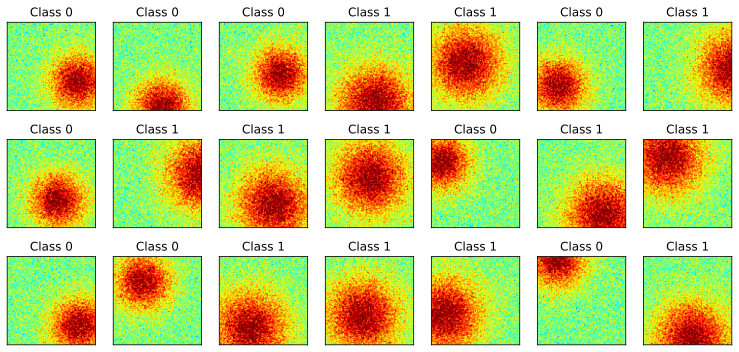

In [74]:
# visualize some images
fig,axs = plt.subplots(3,7,figsize=(13,6))

for i,ax in enumerate(axs.flatten()):
  whichpic = np.random.randint(2*nPerClass)
  G = np.squeeze( images[whichpic,:,:] )
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
  ax.set_title('Class %s'%int(labels[whichpic].item()))
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Create train/test groups using DataLoader

In [75]:
# Step 2: use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(images, labels, test_size=.1)

# Step 3: convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [76]:
# check size (should be images X channels X width X height
print( train_loader.dataset.tensors[0].shape )
print( train_loader.dataset.tensors[1].shape )

torch.Size([1800, 1, 91, 91])
torch.Size([1800, 1])


# Create the DL model

In [98]:
# create a class for the model
def makeTheNet(fc1units=50):

  class gausnet(nn.Module):
    def __init__(self, fc1units=fc1units):
      super().__init__()

      self.conv1 = nn.Conv2d(1,6,3,padding=1)  # output size: (91+2*1-3)/1 + 1 = 91
      self.conv2 = nn.Conv2d(6,4,3,padding=1)  # output size: (45+2*1-3)/1 + 1 = 45

      self.fc1 = nn.Linear(22*22*4,2*fc1units)  # output size: 50
      self.fc2 = nn.Linear(2*fc1units,fc1units)
      self.out = nn.Linear(fc1units,1)          # output size: 1
      
    def forward(self,x):
      # return self.enc(x)

      # pass through conv layers
      x = F.avg_pool2d(F.relu(self.conv1(x)),2)
      x = F.avg_pool2d(F.relu(self.conv2(x)),2)

      # reshape
      nUnits = x.shape.numel() / x.shape[0]
      x = x.view(-1,int(nUnits))

      x = self.fc1(x)
      x = self.fc2(F.relu(x))
      x = self.out(x)

      return x
  
  # create the model instance
  net = gausnet()
  
  # loss function
  lossfun = nn.BCEWithLogitsLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.001)

  return net,lossfun,optimizer

In [78]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet(fc1units=100)

X,y = next(iter(train_loader))
X = X.to(device)
y = y.to(device)
net = net.to(device)
yHat = net(X)

# check size of output
print(' ')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,y)
print(' ')
print('Loss:')
print(loss)

 
torch.Size([32, 1])
 
Loss:
tensor(0.6975, device='cuda:0',
       grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [79]:
# count the total number of parameters in the model
summary(net,(1,imgSize,imgSize))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 6, 91, 91]              60
            Conv2d-2            [-1, 4, 45, 45]             220
            Linear-3                  [-1, 200]         387,400
            Linear-4                  [-1, 100]          20,100
            Linear-5                    [-1, 1]             101
Total params: 407,881
Trainable params: 407,881
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.03
Forward/backward pass size (MB): 0.44
Params size (MB): 1.56
Estimated Total Size (MB): 2.03
----------------------------------------------------------------


# Create a function that trains the model

In [80]:
# a function that trains the model

def function2trainTheModel(fc1units=100):

  # number of epochs
  numepochs = 10
  
  # create a new model
  net,lossfun,optimizer = makeTheNet(fc1units=fc1units)

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  testLoss  = torch.zeros(numepochs)
  trainAcc  = torch.zeros(numepochs)
  testAcc   = torch.zeros(numepochs)

  net = net.to(device)

  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    batchLoss = []
    batchAcc  = []
    for X,y in train_loader:
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())
      batchAcc.append( torch.mean(( (yHat>0) ==y).float()).item() )
    # end of batch loop...

    # and get average losses across the batches
    trainLoss[epochi] = np.mean(batchLoss)
    trainAcc[epochi]  = 100*np.mean(batchAcc)

    # test accuracy
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    X = X.to(device)
    y = y.to(device)
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      loss = lossfun(yHat,y)
      
    # compare the following really long line of code to the training accuracy lines
    testLoss[epochi] = loss.item()
    testAcc[epochi]  = 100*torch.mean(( (yHat>0) ==y).float()).item()

  # end epochs

  # function output
  return trainLoss,testLoss,trainAcc,testAcc,net

# Run the model and show the results!

In [99]:
avgTrainLoss = torch.zeros(len(setUnitsfc1))
avgTestLoss  = torch.zeros(len(setUnitsfc1))
avgTrainAcc  = torch.zeros(len(setUnitsfc1))
avgTestAcc   = torch.zeros(len(setUnitsfc1))

for index, fc1units in enumerate(setUnitsfc1):
    trainLoss,testLoss,trainAcc,testAcc,net = function2trainTheModel(fc1units=fc1units)
    avgTrainLoss[index] = torch.mean(trainLoss[-3:])
    avgTestLoss[index]  = torch.mean(testLoss[-3:])
    avgTrainAcc[index]  = torch.mean(trainAcc[-3:])
    avgTestAcc[index]   = torch.mean(testAcc[-3:])

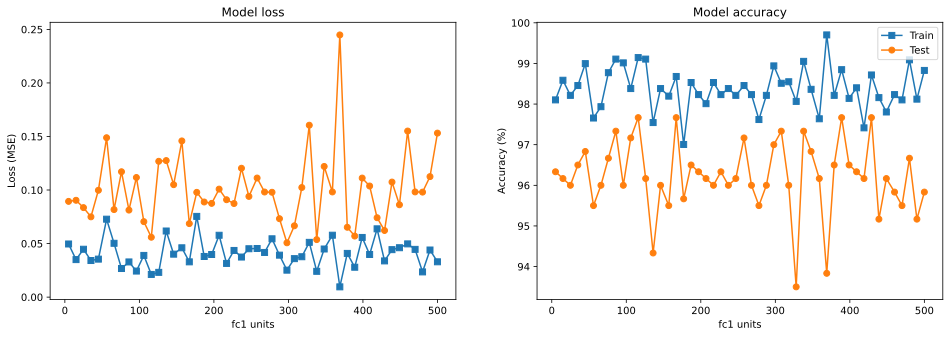

In [100]:
fig,ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(setUnitsfc1, avgTrainLoss, 's-', label='Train')
ax[0].plot(setUnitsfc1, avgTestLoss, 'o-', label='Test')
ax[0].set_xlabel('fc1 units')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model loss')

ax[1].plot(setUnitsfc1, avgTrainAcc, 's-', label='Train')
ax[1].plot(setUnitsfc1, avgTestAcc, 'o-', label='Test')
ax[1].set_xlabel('fc1 units')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title('Model accuracy')
ax[1].legend()

plt.show()

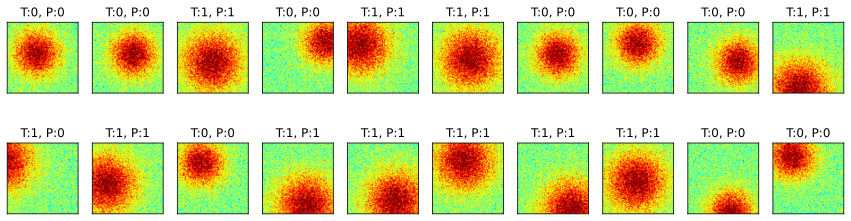

In [93]:
# visualize some images

X,y = next(iter(test_loader)) # extract X,y from test dataloader
X = X.to(device)
y = y.to(device)
yHat = net(X)

fig,axs = plt.subplots(2,10,figsize=(15,4))

for i,ax in enumerate(axs.flatten()):
  G = torch.squeeze( X[i,0,:,:] ).detach()
  G = G.cpu().numpy()
  ax.imshow(G,vmin=-1,vmax=1,cmap='jet')
  t = ( int(y[i].item()) , int(yHat[i].item()>0) )
  ax.set_title('T:%s, P:%s'%t)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

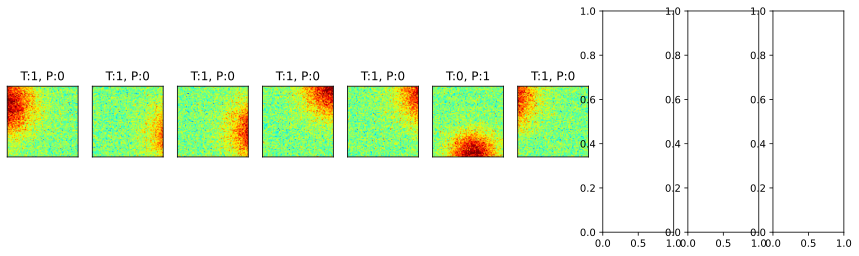

In [94]:
# visualize the errored images
fig,ax = plt.subplots(1,10,figsize=(15,4))

imagecounter = 0
for i in range(X.shape[0]):
    if y[i] != (yHat[i]>0):
        G = torch.squeeze( X[i,0,:,:] ).detach()
        G = G.cpu().numpy()
        ax[imagecounter].imshow(G,vmin=-1,vmax=1,cmap='jet')
        t = ( int(y[i].item()) , int(yHat[i].item()>0) )
        ax[imagecounter].set_title('T:%s, P:%s'%t)
        ax[imagecounter].set_xticks([])
        ax[imagecounter].set_yticks([])
        imagecounter += 1

In [95]:
# look at the filters
print(net)

layer1W = net.conv1.weight
layer3W = net.conv2.weight

print(' ')
print(layer1W.shape)
print(layer3W.shape)

gausnet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(6, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1936, out_features=1000, bias=True)
  (fc2): Linear(in_features=1000, out_features=500, bias=True)
  (out): Linear(in_features=500, out_features=1, bias=True)
)
 
torch.Size([6, 1, 3, 3])
torch.Size([4, 6, 3, 3])


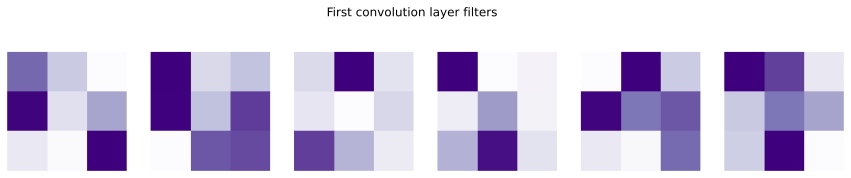

In [96]:
fig,axs = plt.subplots(1,6,figsize=(15,3))

for i,ax in enumerate(axs.flatten()):
  layer1W = layer1W.cpu()
  ax.imshow( torch.squeeze(layer1W[i,:,:,:]).detach() ,cmap='Purples')
  ax.axis('off')

plt.suptitle('First convolution layer filters')
plt.show()

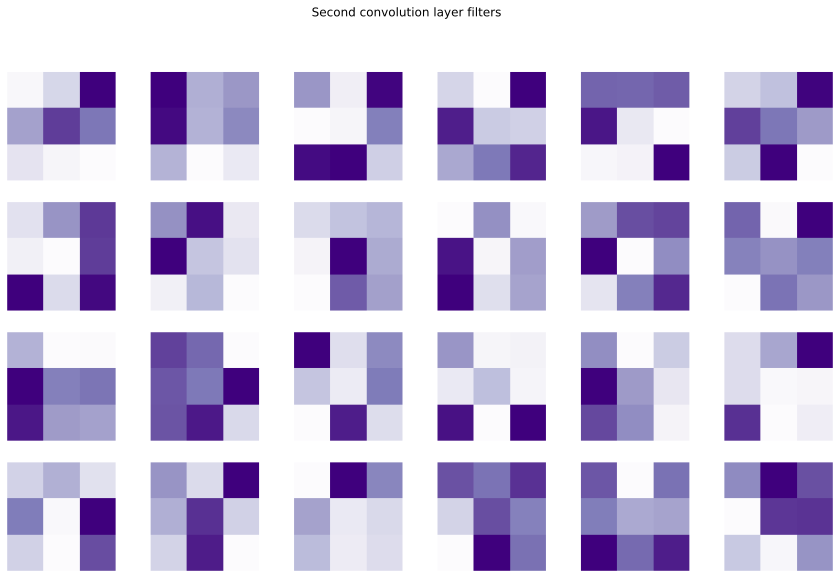

In [97]:
fig,axs = plt.subplots(4,6,figsize=(15,9))

for i in range(6*4):
  idx = np.unravel_index(i,(4,6))  
  layer3W = layer3W.cpu()
  axs[idx].imshow( torch.squeeze(layer3W[idx[0],idx[1],:,:]).detach() ,cmap='Purples')
  axs[idx].axis('off')

plt.suptitle('Second convolution layer filters')
plt.show()